# Project 6 - The Sharpness Quest 

## Imports 

In [1]:
import torch
import torch.nn as nn

from torch.utils.data  import DataLoader
from torchvision.datasets import MNIST
import torch.nn.functional as F
import torchvision.utils
from torch.utils.data import TensorDataset


from tqdm import tqdm
import numpy as np
import random
import matplotlib.pyplot as plt
import os
import pickle
from torchvision.utils import make_grid

# use the GPU when available, otherwise fall back to CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)


device: cuda


In [2]:
print("file size:", os.path.getsize('mnist_custom.pt'), "bytes (expected 112562040)")

d = torch.load('mnist_custom.pt', map_location='cpu', weights_only=False)

for k, v in d.items():
    print(k, tuple(v.shape), v.dtype, "min", float(v.min()), "max", float(v.max()))

bs_train = 1000
bs_test  = 1000

train_dataset = TensorDataset(d['train_images'], d['train_labels'])
test_dataset  = TensorDataset(d['test_images'],  d['test_labels'])

train_dataloader = DataLoader(train_dataset, batch_size=bs_train, shuffle=True,  num_workers=0)
test_dataloader  = DataLoader(test_dataset,  batch_size=bs_test,  shuffle=False, num_workers=0)

# check one batch
x, y = next(iter(train_dataloader))
print("batch:", x.shape, y.shape)

file size: 112562040 bytes (expected 112562040)
train_images (60000, 1, 20, 20) torch.float32 min 0.0 max 1.0
train_labels (60000,) torch.int64 min 0.0 max 9.0
test_images (10000, 1, 20, 20) torch.float32 min 0.0 max 1.0
test_labels (10000,) torch.int64 min 0.0 max 9.0
batch: torch.Size([1000, 1, 20, 20]) torch.Size([1000])


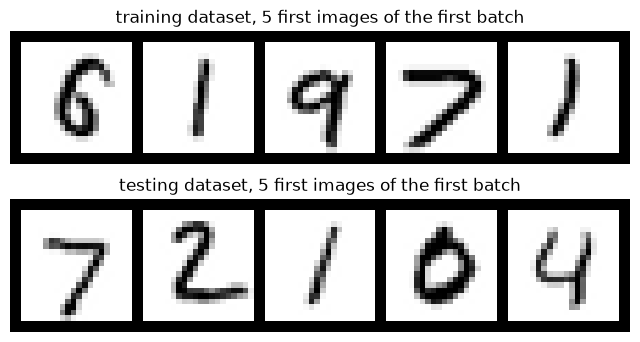

In [3]:
#%% create a figure showing one image per class
figure = plt.figure(figsize=(8, 4))
cols, rows = 3, 3

data,cond = next(iter(train_dataloader))
from torchvision.utils import make_grid
displayImage = make_grid(data[0:5], nrow = 5).permute(1, 2, 0) # need to scale back for display the effect of the normalisation
figure.add_subplot(2, 1, 1)
plt.title('training dataset, 5 first images of the first batch')
plt.axis("off")
plt.imshow(displayImage)

data,cond = next(iter(test_dataloader))
displayImage = make_grid(data[0:5], nrow = 5).permute(1, 2, 0) # need to scale back for display the effect of the normalisation
figure.add_subplot(2, 1, 2)
plt.title('testing dataset, 5 first images of the first batch')
plt.axis("off")
plt.imshow(displayImage)

plt.savefig('task1_fig1', dpi=300, transparent=False)
plt.show()

### Create an encoder 

In [4]:
# Create an encoder to encode the 1x20x20 images into a latent vector of dimension z_dim
class cEncoder(nn.Module):
    def __init__(self, z_dim, num_classes):
        super(cEncoder, self).__init__()
        self.z_dim = z_dim
        self.num_classes = num_classes
        # Define the encoder layers
        self.encoder_backbone = nn.Sequential(
            # Layer 1: 1x20x20 -> 16x10x10
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            # Layer 2: 16x10x10 -> 32x5x5
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            # Layer 3: 32x5x5 -> 64x3x3
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            # Layer 4: 64x3x3 -> 256x1x1 (kernel 3 instead of 4 for the 20x20 dataset)
            nn.Conv2d(64, 256, kernel_size=3, stride=1, padding=0),
            nn.ReLU(),
            # Flatten and project to z_dim
            nn.Flatten(),  # 256*1*1 = 256
        )
        self.encoder_head = nn. Sequential(
           nn.Linear(256+num_classes, 2*z_dim)
        )
         
    def forward(self, x, cond):
        # x shape: (batch_size, 1, 20, 20)        
        # TODO: Implement the encoder network to map x, cond to mu and log-var
        x = self.encoder_backbone(x)
        x = torch.cat([x, cond], dim =1)
        x = self.encoder_head(x)
        mu, logvar=torch.chunk(x, 2, dim=1)
        return mu,logvar

### Create a Decoder

In [5]:
class cDecoder(nn.Module):
    def __init__(self, z_dim, num_classes):
        super(cDecoder, self).__init__()
        self.z_dim = z_dim
        self.num_classes = num_classes
        self.decoder_input =  nn.Sequential(
            # Project latent vector to a feature map
            nn.Linear(z_dim + num_classes, 256), 
            nn.ReLU(),
        )
        self.decoder_backbone = nn.Sequential(
            nn.Unflatten(1, (256, 1, 1)),  # Reshape to (256, 1, 1)
            # Layer 1: 256x1x1 -> 64x5x5
            nn.ConvTranspose2d(256, 64, kernel_size=5, stride=1, padding=0),
            nn.ReLU(),
            # Layer 2: 64x5x5 -> 32x10x10
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            # Layer 3: 32x10x10 -> 16x20x20
            nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            # Layer 4: 16x20x20 -> 1x20x20
            nn.Conv2d(16, 1, kernel_size=3, padding=1),
            nn.Sigmoid()  # Output in [0, 1] for pixel values
        )

    def forward(self, z, cond):
        # z shape: (batch_size, z_dim)
        # cond shape: (batch_size, num_classes)
        #TODO: inplement the decoder to generate a new sample from a latent vector and condition
        x = self.decoder_input(torch.cat([z, cond], dim=1))
        x_hat = self.decoder_backbone(x)
        return x_hat

### CVAE Loss

In [6]:
def compute_loss(x, x_hat, mu, logvar, beta=0.1):
    """
    Compute the reconstruction loss for the autoencoder.
    """

    # Reconstruction loss (MSE)

    recon_loss = F.mse_loss(x, x_hat)
    recon_loss = 100*recon_loss

    # For standard autoencoder, KL divergence is 0
    if beta == 0:
        kl_loss = 0.0
    else:
        kl_loss = torch.mean(-0.5 * torch.sum(1 + logvar - mu**2 - logvar.exp(), dim=1))

    # Total loss
    total_loss = recon_loss + beta * kl_loss

    return total_loss, recon_loss, kl_loss

### Setting model 

In [7]:
class cVAE(nn.Module):
    def __init__(self, z_dim, num_classes):
        super(cVAE, self).__init__()
        self.encoder = cEncoder(z_dim, num_classes)
        self.decoder = cDecoder(z_dim, num_classes)
        self.z_dim =  z_dim
        self.num_classes = num_classes
    
    def encode(self,x,cond):
        return self.encoder(x,cond)

    def decode(self,z,cond):
        return self.decoder(z,cond)
    
    def forward(self, x, cond):
        mu,logvar = self.encoder(x, cond)
        # TODO: implement the reparametrization trick to sample the latent z
        sigma = (0.5 *logvar).exp()
        eps = torch.randn_like(sigma)
        z = mu + sigma * eps 
        x_recon = self.decoder(z, cond)
        return x_recon,mu,logvar

### Dimension Set and Check

In [8]:
# parameters
z_dim = 7

# create the model and move it to the device
model = cVAE(z_dim,num_classes = 10)
model = model.to(device)

print(model)

print("\n---total number of parameters:")
Nparams = sum(p.numel() for p in model.parameters())
print(Nparams)
print("---total number of trainable parameters:")
Nparams_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(Nparams_train)
print()

# shape check on one batch: output must match the 20x20 input
x, y = next(iter(train_dataloader))
x_hat, mu, logvar = model(x.to(device), F.one_hot(y, 10).float().to(device))
print('input', tuple(x.shape), '-> recon', tuple(x_hat.shape), '| mu', tuple(mu.shape))
assert x_hat.shape == x.shape


cVAE(
  (encoder): cEncoder(
    (encoder_backbone): Sequential(
      (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (3): ReLU()
      (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (5): ReLU()
      (6): Conv2d(64, 256, kernel_size=(3, 3), stride=(1, 1))
      (7): ReLU()
      (8): Flatten(start_dim=1, end_dim=-1)
    )
    (encoder_head): Sequential(
      (0): Linear(in_features=266, out_features=14, bias=True)
    )
  )
  (decoder): cDecoder(
    (decoder_input): Sequential(
      (0): Linear(in_features=17, out_features=256, bias=True)
      (1): ReLU()
    )
    (decoder_backbone): Sequential(
      (0): Unflatten(dim=1, unflattened_size=(256, 1, 1))
      (1): ConvTranspose2d(256, 64, kernel_size=(5, 5), stride=(1, 1))
      (2): ReLU()
      (3): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    

## Training the baseline cVAE


In [9]:
torch.manual_seed(0); np.random.seed(0); random.seed(0)

def run_epoch(model, loader, beta, opt=None):
    """One pass over the loader. Trains if an optimiser is given, otherwise evaluates.
    Returns the mean [total, recon, kl] loss over the batches."""
    model.train(opt is not None)
    tot = np.zeros(3); n = 0
    with torch.set_grad_enabled(opt is not None):
        for x, y in loader:
            x = x.to(device)
            c = F.one_hot(y, 10).float().to(device)
            x_hat, mu, logvar = model(x, c)
            loss, rec, kl = compute_loss(x, x_hat, mu, logvar, beta)
            if opt is not None:
                opt.zero_grad()
                loss.backward()
                opt.step()
            tot += [loss.item(), rec.item(), float(kl)]
            n += 1
    return tot / n

n_epochs = 100
beta = 0.1

model = cVAE(z_dim, num_classes=10).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
history = {'train': [], 'test': []}

for epoch in tqdm(range(n_epochs)):
    history['train'].append(run_epoch(model, train_dataloader, beta, opt))
    history['test'].append(run_epoch(model, test_dataloader, beta))
    if epoch % 10 == 0 or epoch == n_epochs - 1:
        tr, te = history['train'][-1], history['test'][-1]
        print(f"epoch {epoch:3d} | train total {tr[0]:.3f} recon {tr[1]:.3f} kl {tr[2]:.3f} "
              f"| test total {te[0]:.3f} recon {te[1]:.3f} kl {te[2]:.3f}")

torch.save(model.state_dict(), 'cvae_baseline.pt')
with open('cvae_baseline_history.pkl', 'wb') as f:
    pickle.dump(history, f)
print('saved cvae_baseline.pt and cvae_baseline_history.pkl')


  0%|          | 0/100 [00:00<?, ?it/s]/tmp/ipykernel_1524/2306194227.py:18: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /__w/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:822.)
  tot += [loss.item(), rec.item(), float(kl)]
  1%|          | 1/100 [00:04<07:51,  4.77s/it]

epoch   0 | train total 10.313 recon 10.164 kl 1.499 | test total 5.894 recon 5.892 kl 0.013


 11%|█         | 11/100 [00:51<06:56,  4.68s/it]

epoch  10 | train total 3.218 recon 2.889 kl 3.292 | test total 3.225 recon 2.901 kl 3.243


 21%|██        | 21/100 [01:38<06:11,  4.71s/it]

...

epoch  80 | train total 2.350 recon 1.674 kl 6.761 | test total 2.387 recon 1.710 kl 6.763


 91%|█████████ | 91/100 [07:08<00:42,  4.71s/it]

epoch  90 | train total 2.333 recon 1.653 kl 6.796 | test total 2.374 recon 1.696 kl 6.779


100%|██████████| 100/100 [07:50<00:00,  4.71s/it]

epoch  99 | train total 2.318 recon 1.635 kl 6.833 | test total 2.364 recon 1.681 kl 6.832
saved cvae_baseline.pt and cvae_baseline_history.pkl


### Loss curves (convergence check)


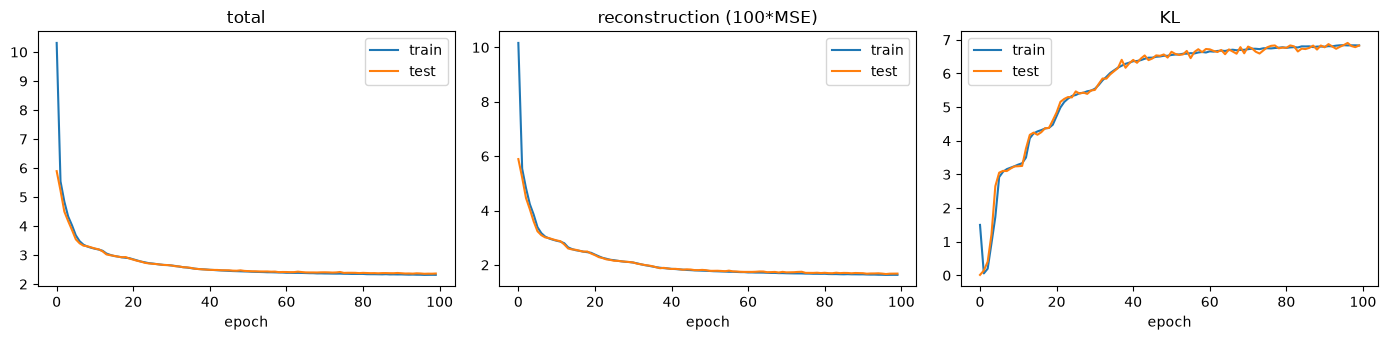

In [10]:
tr = np.array(history['train']); te = np.array(history['test'])
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
for i, name in enumerate(['total', 'reconstruction (100*MSE)', 'KL']):
    axes[i].plot(tr[:, i], label='train')
    axes[i].plot(te[:, i], label='test')
    axes[i].set_title(name); axes[i].set_xlabel('epoch'); axes[i].legend()
plt.tight_layout()
plt.savefig('baseline_losses.png', dpi=300)
plt.show()


### Conditional sampling: 12 samples per digit (12x10 grid)


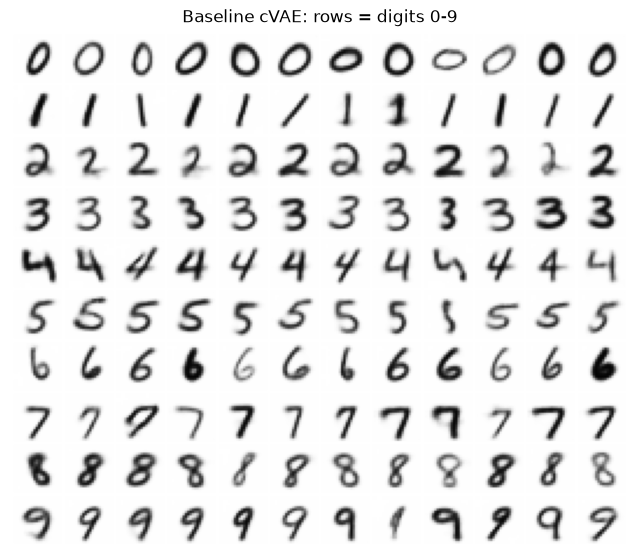

In [12]:
@torch.no_grad()
def sample_grid(model, n_per_class=12, seed=0, title=None):
    """Decode n_per_class prior samples for each digit 0-9.
    A fixed seed gives identical latent vectors across models, for a fair comparison."""
    model.eval()
    g = torch.Generator(device='cpu').manual_seed(seed)
    y = torch.arange(10).repeat_interleave(n_per_class)
    z = torch.randn(len(y), model.z_dim, generator=g).to(device)
    x = model.decode(z, F.one_hot(y, 10).float().to(device)).cpu()
    grid = make_grid(x, nrow=n_per_class, pad_value=1)
    plt.figure(figsize=(8, 7))
    plt.imshow(grid.permute(1, 2, 0))
    plt.axis('off')
    if title: plt.title(title)
    return x

samples_baseline = sample_grid(model, title='Baseline cVAE: rows = digits 0-9')
plt.savefig('baseline_samples_grid.png', dpi=150)
plt.show()
